# 📷 CIFAR-10: Feature Extraction & SVM Classification (Test - V2)

Notebook ini mengevaluasi model CNN dan SVM yang sudah dilatih pada dataset testing CIFAR-10 (10.000 sampel).

### 🌟 Karakteristik Utama Versi 2 (Single File .keras & Murni Test):
1. **Murni Data Test**: Hanya memuat `X_test` dan `y_test`. Data training sama sekali **tidak dimuat** di notebook ini.
2. **Bebas Training di Test**: Tidak ada proses `fit()` pada notebook ini. Model SVM Pipeline (`StandardScaler` + `SVC RBF`) dimuat langsung dari file `.keras`.
3. **Satu File Model Saja**: CNN dan SVM disimpan bersama di dalam satu file tunggal: `custom_cnn_cifar10_feature_extraction.keras` via format HDF5.
4. **Target Akurasi**: Menargetkan performa klasifikasi SVM > **86%** pada data test CIFAR-10.

# 📚 1. Importing Libraries

In [1]:
import os
import random
import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# CUDA DLL configuration for Windows environment
conda_prefix = os.environ.get('CONDA_PREFIX', r'C:\Users\daffa\anaconda3\envs\CNNgpu')
cuda_bin = os.path.join(conda_prefix, 'Library', 'bin')
if hasattr(os, 'add_dll_directory') and os.path.exists(cuda_bin):
    try:
        os.add_dll_directory(cuda_bin)
    except Exception:
        pass
os.environ['PATH'] = cuda_bin + ';' + os.environ.get('PATH', '')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Flatten, GlobalAveragePooling2D

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Seed Reproducibility: 23092026
RANDOM_STATE = 23092026
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version: 2.10.1
GPU available: True


# 📥 2. Load Dataset

In [2]:
# HANYA MEMUAT DATA TESTING! Data training sama sekali tidak dimuat di notebook ini.
_, (X_test, y_test) = cifar10.load_data()

print(f"X_test shape (murni untuk evaluasi): {X_test.shape}")
print(f"y_test shape (murni untuk evaluasi): {y_test.shape}")
print("\n[VERIFIKASI] Data training TIDAK dimuat di notebook test ini.")


X_test shape (murni untuk evaluasi): (10000, 32, 32, 3)
y_test shape (murni untuk evaluasi): (10000, 1)

[VERIFIKASI] Data training TIDAK dimuat di notebook test ini.


# 🖼 3. Visualisasi Data Test

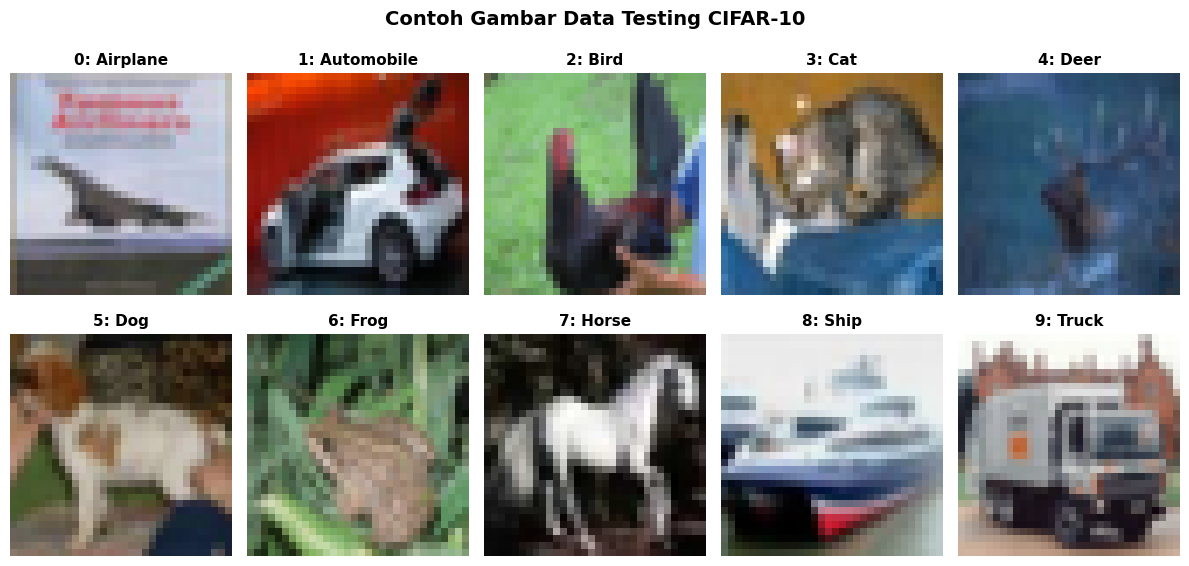

In [3]:
classes_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
                'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Visualisasi contoh data testing
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    index = np.where(y_test == i)[0][0]
    axes[i].imshow(X_test[index])
    axes[i].set_title(f"{i}: {classes_name[i]}", fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Contoh Gambar Data Testing CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ⚙️ 4. Pre-processing Data Test

Data testing dinormalisasi ke rentang `[0, 1]` dengan membagi nilai piksel dengan `255.0`.
Label disiapkan dalam bentuk flat (1D) untuk SVM dan categorical (one-hot) untuk CNN.

In [4]:
# Normalisasi data piksel testing ke rentang [0, 1]
X_test = X_test.astype('float32') / 255.0

# Flatten label untuk evaluasi SVM
y_test_flat = y_test.flatten()

# One-hot encoding untuk evaluasi model CNN
y_cat_test = to_categorical(y_test, 10)

print(f"X_test shape     : {X_test.shape}")
print(f"y_test_flat shape: {y_test_flat.shape}")
print(f"y_cat_test shape : {y_cat_test.shape}")


X_test shape     : (10000, 32, 32, 3)
y_test_flat shape: (10000,)
y_cat_test shape : (10000, 10)


# 📥 5. Load Trained CNN & SVM Pipeline dari Satu File `.keras`

Kita memuat model dari satu-satunya file output:
```
custom_cnn_cifar10_feature_extraction.keras
```
- Model CNN dimuat menggunakan `load_model()`.
- Model SVM Pipeline (`StandardScaler` + `SVC RBF`) dimuat dari dataset HDF5 `/svm_pipeline_pickle` menggunakan `h5py`.

In [5]:
cnn_model_filename = 'custom_cnn_cifar10_feature_extraction.keras'

# Fallback otomatis jika file .keras belum ada namun file .h5 tersedia
if not os.path.exists(cnn_model_filename) and os.path.exists('custom_cnn_cifar10_feature_extraction.h5'):
    cnn_model_filename = 'custom_cnn_cifar10_feature_extraction.h5'

if not os.path.exists(cnn_model_filename):
    raise FileNotFoundError(
        f"{cnn_model_filename} tidak ditemukan! "
        "Pastikan Anda telah menjalankan notebook 'cifar10_train.ipynb' terlebih dahulu."
    )

# 1. Memuat model CNN (Keras)
print(f"Memuat model CNN dari: {cnn_model_filename}")
cnn_model = load_model(cnn_model_filename)
cnn_model.summary()

# 2. Memuat model SVM Pipeline dari dataset di dalam file yang sama via h5py
print(f"\nMemuat SVM Pipeline dari dataset '/svm_pipeline_pickle' di dalam file {cnn_model_filename}...")
with h5py.File(cnn_model_filename, 'r') as h5f:
    if 'svm_pipeline_pickle' not in h5f:
        raise KeyError(
            f"Dataset 'svm_pipeline_pickle' tidak ditemukan dalam file {cnn_model_filename}! "
            "Pastikan cell penyimpanan akhir pada notebook training sudah dijalankan."
        )
    svm_bytes = bytes(h5f['svm_pipeline_pickle'][()])
    svm_pipeline = pickle.loads(svm_bytes)
    feature_layer_name = h5f.attrs.get('feature_layer', 'svm_features')
    if isinstance(feature_layer_name, bytes):
        feature_layer_name = feature_layer_name.decode('utf-8')

print(f"\n[BERHASIL] CNN dan SVM Pipeline berhasil dimuat dari SATU FILE ({cnn_model_filename}) yang sama!")
print(f"SVM Pipeline: {svm_pipeline}")
print(f"Feature Layer Terdaftar: {feature_layer_name}")

# Evaluasi performa CNN pada test set
print("\n--- Evaluasi Model CNN pada Test Set ---")
cnn_eval = cnn_model.evaluate(X_test, y_cat_test, verbose=1)
cnn_test_loss = cnn_eval[0]
cnn_test_acc = cnn_eval[1]
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy : {cnn_test_acc * 100:.2f}%")


Memuat model CNN dari: custom_cnn_cifar10_feature_extraction.h5
Model: "custom_cnn_cifar10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 32, 32, 3)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 32, 32, 64)        1792      
                                                                 
 bn1_1 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 conv1_2 (Conv2D)            (None, 32, 32, 64)        36928     
                                                                 
 bn1_2 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 64)        0         
                                                  

# 🧠 6. Feature Extraction via CNN (`svm_features` / GlobalAveragePooling2D)

Mengekstrak representasi fitur berdimensi 512 dari layer `svm_features` pada model CNN yang telah dilatih.


In [6]:
# Cari layer ekstraksi fitur pada model CNN kustom
feature_layer = None
if 'feature_layer_name' in locals() and feature_layer_name:
    try:
        feature_layer = cnn_model.get_layer(feature_layer_name)
    except Exception:
        pass

if feature_layer is None:
    for layer in cnn_model.layers:
        if 'svm_features' in layer.name or isinstance(layer, GlobalAveragePooling2D):
            feature_layer = layer
            break

if feature_layer is None:
    for layer in cnn_model.layers:
        if isinstance(layer, Flatten):
            feature_layer = layer
            break

feature_extractor = Model(inputs=cnn_model.input, outputs=feature_layer.output)
print(f"Feature extractor layer: {feature_layer.name}, Dimensi fitur: {feature_layer.output_shape[-1]}")

# Ekstraksi fitur secara bertahap dari data testing (10.000 sampel) agar aman dari GPU OOM
chunk_size = 5000
test_features_list = []
total_test = len(X_test)
print(f"\nMengekstrak fitur dari data testing ({total_test} sampel)... Mohon tunggu...")

for i in range(0, total_test, chunk_size):
    end_idx = min(i + chunk_size, total_test)
    chunk_feat = feature_extractor.predict(X_test[i:end_idx], batch_size=64, verbose=0)
    test_features_list.append(chunk_feat)

X_test_features = np.vstack(test_features_list)
print(f"\n[SELESAI] X_test_features shape : {X_test_features.shape}")


Feature extractor layer: svm_features, Dimensi fitur: 512

Mengekstrak fitur dari data testing (10000 sampel)... Mohon tunggu...

[SELESAI] X_test_features shape : (10000, 512)


# ⚔️ 7. Evaluasi SVM Classifier 

Karena model SVM Pipeline (`StandardScaler` + `SVC RBF`) sudah dilatih di notebook training dan dimuat dari file `.keras`,
di sini kita **langsung melakukan prediksi dan evaluasi** pada fitur data test.

In [7]:
print("=" * 60)
print("  PREDIKSI & EVALUASI SVM CLASSIFIER PADA TEST SET")
print("=" * 60)

# Prediksi langsung dengan SVM Pipeline (sudah termasuk penskalaan StandardScaler internal)
print("Menjalankan prediksi menggunakan SVM Pipeline yang dimuat dari file model (.keras)...")
y_pred_svm = svm_pipeline.predict(X_test_features)
acc_svm = accuracy_score(y_test_flat, y_pred_svm)

print(f"\n[HASIL] SVM RBF Test Accuracy: {acc_svm * 100:.2f}%")


  PREDIKSI & EVALUASI SVM CLASSIFIER PADA TEST SET
Menjalankan prediksi menggunakan SVM Pipeline yang dimuat dari file .h5...

[HASIL] SVM RBF Test Accuracy: 92.16%


# 📊 8. Perbandingan Hasil: CNN vs SVM & Pengecekan Target >86%

Membandingkan akurasi CNN murni vs Feature Extraction + SVM Classifier terhadap target >86%.

Model Terbaik : CNN Kustom dengan Akurasi: 92.43%

 [SUKSES] TARGET AKURASI TERCAPAI: 92.43% >= 86.00%!


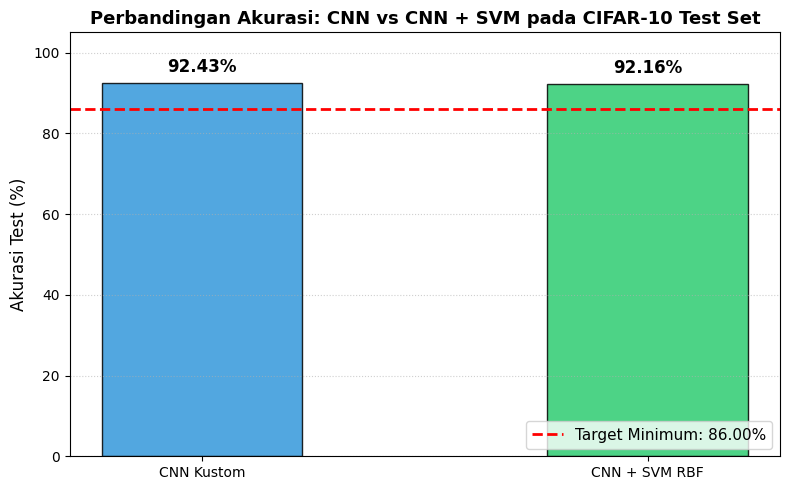

In [8]:
# Tentukan model terbaik pada data test
models_acc = {
    'CNN Kustom': cnn_test_acc,
    'CNN + SVM RBF': acc_svm
}

best_model_name = max(models_acc, key=models_acc.get)
best_acc = models_acc[best_model_name]

print(f"Model Terbaik : {best_model_name} dengan Akurasi: {best_acc * 100:.2f}%")
if best_acc >= 0.86:
    print("\n============================================================")
    print(f" [SUKSES] TARGET AKURASI TERCAPAI: {best_acc * 100:.2f}% >= 86.00%!")
    print("============================================================")
else:
    print(f"\n[INFO] Akurasi saat ini: {best_acc * 100:.2f}%")

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(8, 5))
names = list(models_acc.keys())
values = [v * 100 for v in models_acc.values()]
colors = ['#3498db', '#2ecc71']

bars = ax.bar(names, values, color=colors, width=0.45, edgecolor='black', alpha=0.85)
ax.axhline(y=86.0, color='red', linestyle='--', linewidth=2, label='Target Minimum: 86.00%')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 105)
ax.set_ylabel('Akurasi Test (%)', fontsize=12)
ax.set_title('Perbandingan Akurasi: CNN vs CNN + SVM pada CIFAR-10 Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# 📋 9. Classification Report & Confusion Matrix

Analisis detail performa per kelas dari model SVM.

  CLASSIFICATION REPORT SVM CLASSIFIER
              precision    recall  f1-score   support

    Airplane       0.92      0.93      0.93      1000
  Automobile       0.96      0.96      0.96      1000
        Bird       0.90      0.91      0.90      1000
         Cat       0.84      0.83      0.83      1000
        Deer       0.92      0.94      0.93      1000
         Dog       0.87      0.86      0.86      1000
        Frog       0.95      0.95      0.95      1000
       Horse       0.95      0.94      0.94      1000
        Ship       0.95      0.96      0.96      1000
       Truck       0.94      0.95      0.94      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



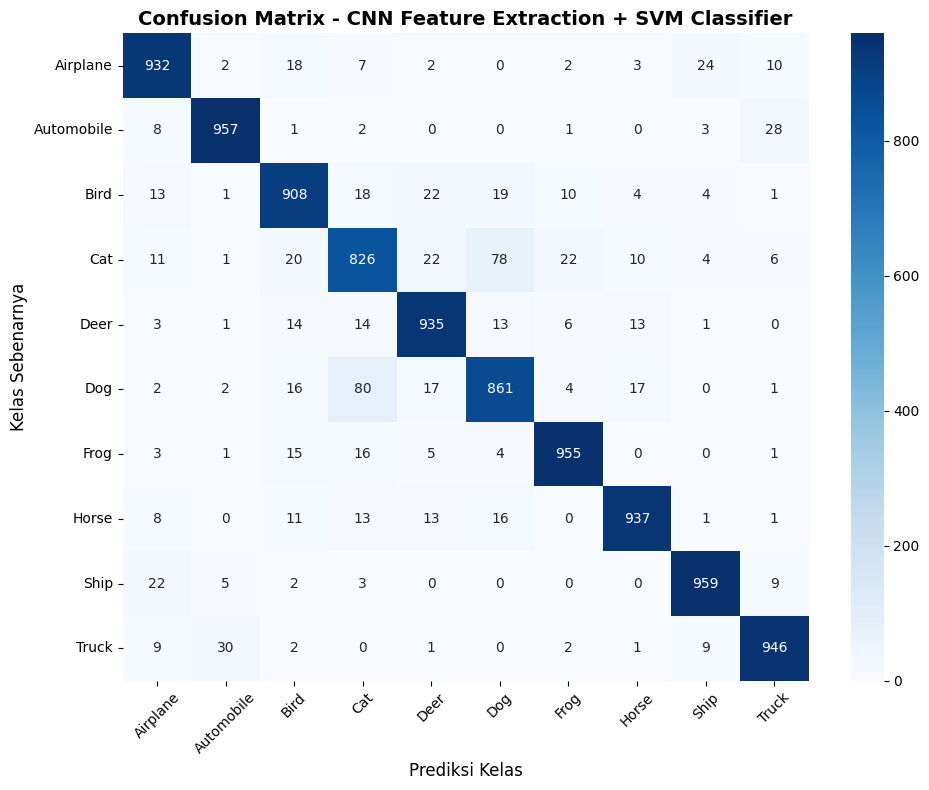

In [9]:
# Classification Report SVM
print("=" * 60)
print("  CLASSIFICATION REPORT SVM CLASSIFIER")
print("=" * 60)
print(classification_report(y_test_flat, y_pred_svm, target_names=classes_name))

# Confusion Matrix
cm = confusion_matrix(y_test_flat, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_name, yticklabels=classes_name)
plt.title('Confusion Matrix - CNN Feature Extraction + SVM Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Kelas', fontsize=12)
plt.ylabel('Kelas Sebenarnya', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 🖼 10. Visualisasi Prediksi SVM pada Gambar Test

Visualisasi 15 sampel gambar acak dari data testing beserta perbandingan label asli dan hasil prediksi SVM.

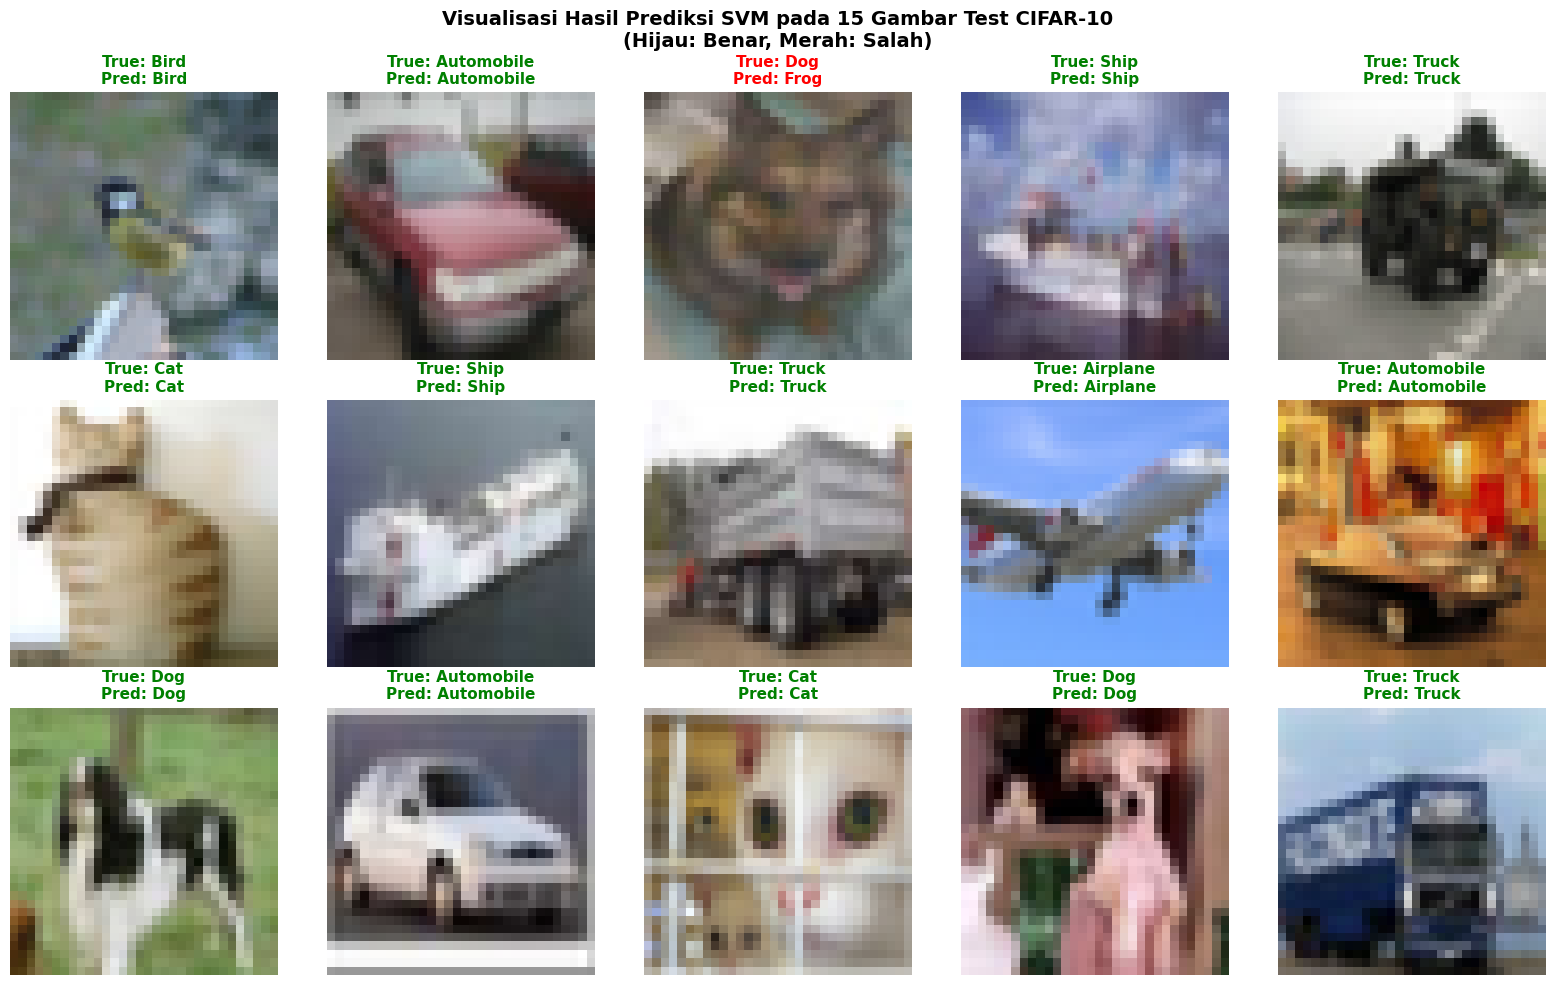

In [10]:
# Visualisasi 15 gambar test acak beserta hasil prediksi SVM
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    true_label = classes_name[y_test_flat[idx]]
    pred_label = classes_name[y_pred_svm[idx]]
    is_correct = (true_label == pred_label)
    
    axes[i].imshow(X_test[idx])
    title_color = 'green' if is_correct else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", 
                      fontsize=11, color=title_color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Visualisasi Hasil Prediksi SVM pada 15 Gambar Test CIFAR-10\n(Hijau: Benar, Merah: Salah)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
